<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula05_producaoindustrialdeproducaofisica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CURSO: Análise de Conjuntura usando Python - Análise Macro<br>
AULA: Coleta e tratamento da Produção Industrial com R e Python<br>
INFORMAÇÕES: saiba mais sobre a Pesquisa Industrial Mensal (PIM-PF/IBGE) no link https://www.ibge.gov.br/estatisticas/economicas/industria/9294-pesquisa-industrial-mensal-producao-fisica-brasil.html<br>
AUTOR: Fernando da Silva/Cientista de dados

# Bibliotecas

In [ ]:
# Instalar bibliotecas
!pip install sidrapy

# Importar as bibliotecas
import sidrapy as sidra
import pandas as pd

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Dados

In [ ]:
# Coleta de dados
dados_brutos = sidra.get_table( #para coletar os dados da tabela
    table_code = "8158",
    territorial_level = "1",
    ibge_territorial_code = "all",
    variable = "11604",
    classifications = {"543": "129278,129283,129300"},
    period = "all"
    )
dados_brutos

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,Variável (Código),Variável,Grandes categorias econômicas (Código),Grandes categorias econômicas
1,1,Brasil,,,...,1,Brasil,200201,janeiro 2002,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129278,1 Bens de capital
2,1,Brasil,,,...,1,Brasil,200201,janeiro 2002,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129283,2 Bens intermediários
3,1,Brasil,,,...,1,Brasil,200201,janeiro 2002,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129300,3 Bens de consumo
4,1,Brasil,,,...,1,Brasil,200202,fevereiro 2002,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129278,1 Bens de capital
...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,1,Brasil,2,%,-2.6,1,Brasil,202206,junho 2022,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129283,2 Bens intermediários
738,1,Brasil,2,%,-6.0,1,Brasil,202206,junho 2022,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129300,3 Bens de consumo
739,1,Brasil,2,%,3.7,1,Brasil,202207,julho 2022,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129278,1 Bens de capital
740,1,Brasil,2,%,-2.6,1,Brasil,202207,julho 2022,11604,PIMPF - Variação acumulada em 12 meses (em rel...,129283,2 Bens intermediários


In [ ]:
# Tratamento de dados
dados = (
    dados_brutos.rename(columns = dados_brutos.iloc[0])
    .rename(
        columns = {
            "Mês (Código)": "data",
             "Grandes categorias econômicas": "categorias",
             "Valor": "valor"
             }
            )
    .query("valor not in ['Valor', '...']") #para remover o que nao quer ou nao precisa
    .filter(items = ["data", "categorias", "valor"], axis = "columns")
    .assign( #para alterar o tipo do dado
        data = lambda x: pd.to_datetime(x.data, format = "%Y%m"),
        valor = lambda y: y.valor.astype(float),
        categorias = lambda z: z.categorias.str.replace("\d ", "") #remover os numeros na frente das palavras com uma expressao regular com rejex
        )
    .pivot(index = "data", columns = "categorias", values = "valor")
)
dados

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:16: FutureWarning: The default value of regex will change from True to False in a future version.
  app.launch_new_instance()


categorias,Bens de capital,Bens de consumo,Bens intermediários
data,,,
2003-12-01,2.4,-2.8,1.9
2004-01-01,3.6,-2.5,1.8
2004-02-01,3.8,-2.7,1.9
2004-03-01,7.6,-1.0,2.1
2004-04-01,10.8,0.3,2.6
...,...,...,...
2022-03-01,20.9,-1.9,1.4
2022-04-01,14.4,-4.1,-0.3
2022-05-01,10.4,-5.7,-1.7


# Visualização de dados

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fb10d76fd50>,
      dtype=object)

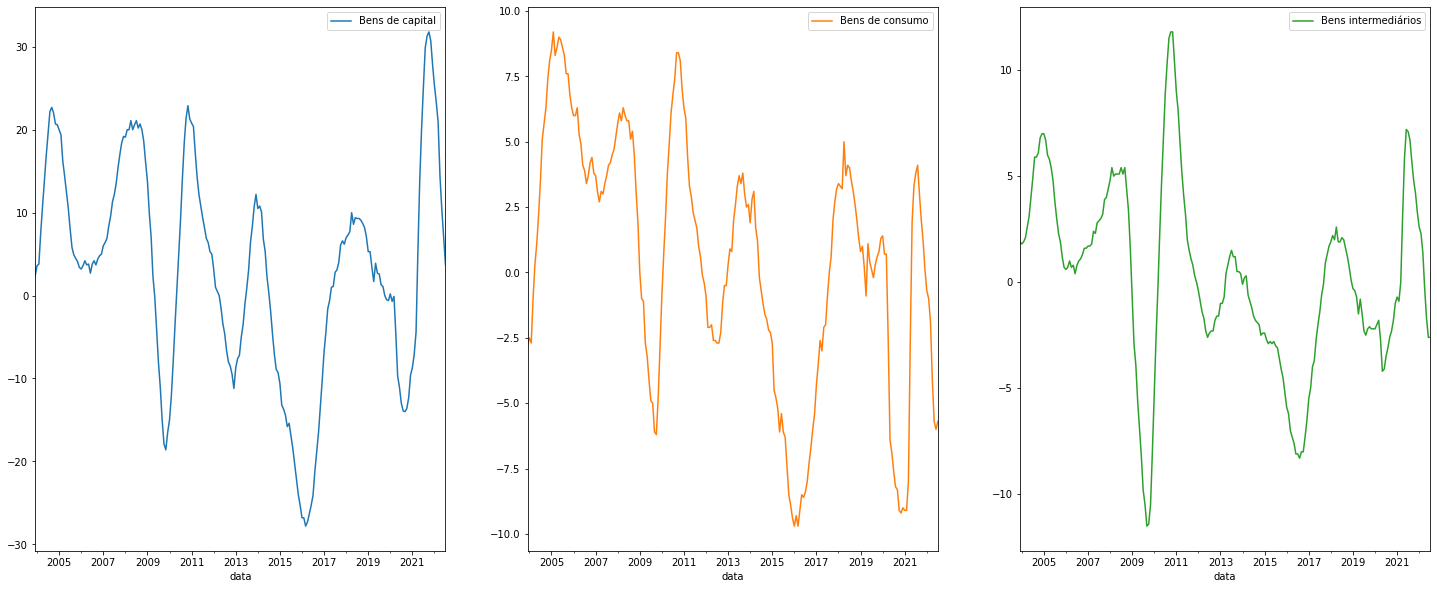

In [ ]:
# Gráfico de linha
dados.plot(subplots = True, layout = (1, 3), figsize = (25, 10))